### 1.Предобработка данных

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm

In [72]:
df_customers = pd.read_csv('olist_customers_dataset.csv')
df_orders = pd.read_csv('olist_orders_dataset.csv')
df_order_items = pd.read_csv('olist_order_items_dataset.csv')

In [73]:
df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [74]:
#С помощью merge присоединим к таблице df_orders уникальный идентификатор пользователя из df_customers
df_orders = pd.merge(df_orders, df_customers, on = 'customer_id', how = 'left')

Для оценки retention в оформление заказа будем учитывать статусы "created", "approved", "invoiced", "processing", "shipped", "delivered"

In [75]:
#Извлечем нужные для подсчёта retention периоды
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'])
df_orders['order_period'] = df_orders['order_purchase_timestamp'].dt.to_period('M')
df_orders['order_period_day'] = df_orders['order_purchase_timestamp'].dt.to_period('D')

In [76]:
#Оставляем заказы только со статусами "created", "approved", "invoiced", "processing", "shipped", "delivered"
df_orders_completed = df_orders[df_orders['order_status'].isin(['created', 'approved', 'invoiced',
                                                               'processing', 'shipped', 'delivered'])].copy()

In [77]:
df_orders_completed['cohort'] = df_orders_completed.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')
df_orders_completed['cohort_day'] = df_orders_completed.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('D')

In [78]:
df_orders_completed['period_number_month'] = np.floor((df_orders_completed['order_period_day'] - df_orders_completed['cohort_day']).apply(lambda x: x.n)/30)

In [79]:
df_cohort = df_orders_completed.groupby(['cohort', 'period_number_month']).agg(customers = ('customer_id', 'nunique')).reset_index()

### Когортный анализ

In [80]:
#Создаем сводную таблицу когорт
df_pivot = df_cohort.pivot_table(columns = 'period_number_month', index = 'cohort', values = 'customers')

In [81]:
df_pivot = df_pivot.fillna(0)
cohort_size = df_pivot.iloc[:, 0]
df_pivot = df_pivot.divide(df_pivot.iloc[:,0], axis = 0)

In [82]:
df_pivot

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2016-10,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.003413,0.000000,0.000000,0.003413,...,0.003413,0.000000,0.003413,0.000000,0.003413,0.000000,0.003413,0.006826,0.003413,0.003413
2016-12,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2017-01,1.0,0.002535,0.000000,0.005070,0.001267,0.001267,0.002535,0.002535,0.000000,0.000000,...,0.005070,0.003802,0.002535,0.000000,0.002535,0.002535,0.002535,0.001267,0.000000,0.000000
2017-02,1.0,0.001746,0.001746,0.003492,0.002328,0.001164,0.002910,0.000582,0.001164,0.002328,...,0.003492,0.000582,0.001746,0.001164,0.000582,0.001164,0.002328,0.000000,0.000000,0.000000
2017-03,1.0,0.002671,0.005341,0.004578,0.001145,0.000763,0.003434,0.001908,0.002671,0.002289,...,0.001908,0.001908,0.001145,0.002671,0.000763,0.001145,0.001145,0.000000,0.000000,0.000000
2017-04,1.0,0.003804,0.002959,0.000423,0.002959,0.003804,0.002536,0.004227,0.002113,0.002536,...,0.001691,0.000000,0.000845,0.000845,0.000845,0.001268,0.000000,0.000000,0.000000,0.000000
2017-05,1.0,0.004143,0.004695,0.003314,0.004143,0.003866,0.003590,0.001105,0.003038,0.002762,...,0.003038,0.002209,0.001105,0.002486,0.001657,0.000000,0.000000,0.000000,0.000000,0.000000
2017-06,1.0,0.003790,0.004738,0.003474,0.001263,0.005054,0.002843,0.001895,0.001263,0.003474,...,0.002527,0.000632,0.002843,0.000948,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [83]:
#Находим медианный retention первого месяца
median_retention = df_pivot.iloc[:, 1].median()
median_retention

0.0035823950870010235

In [84]:
#Находим когорту с самым большим retention за третий месяц
month3_max = df_pivot.iloc[:, 3].max()
cohort3_max = df_pivot[df_pivot.iloc[:, 3] == month3_max].index
cohort3_max


PeriodIndex(['2017-01'], dtype='period[M]', name='cohort')

In [85]:
sns.set_style('darkgrid')

<Axes: ylabel='cohort'>

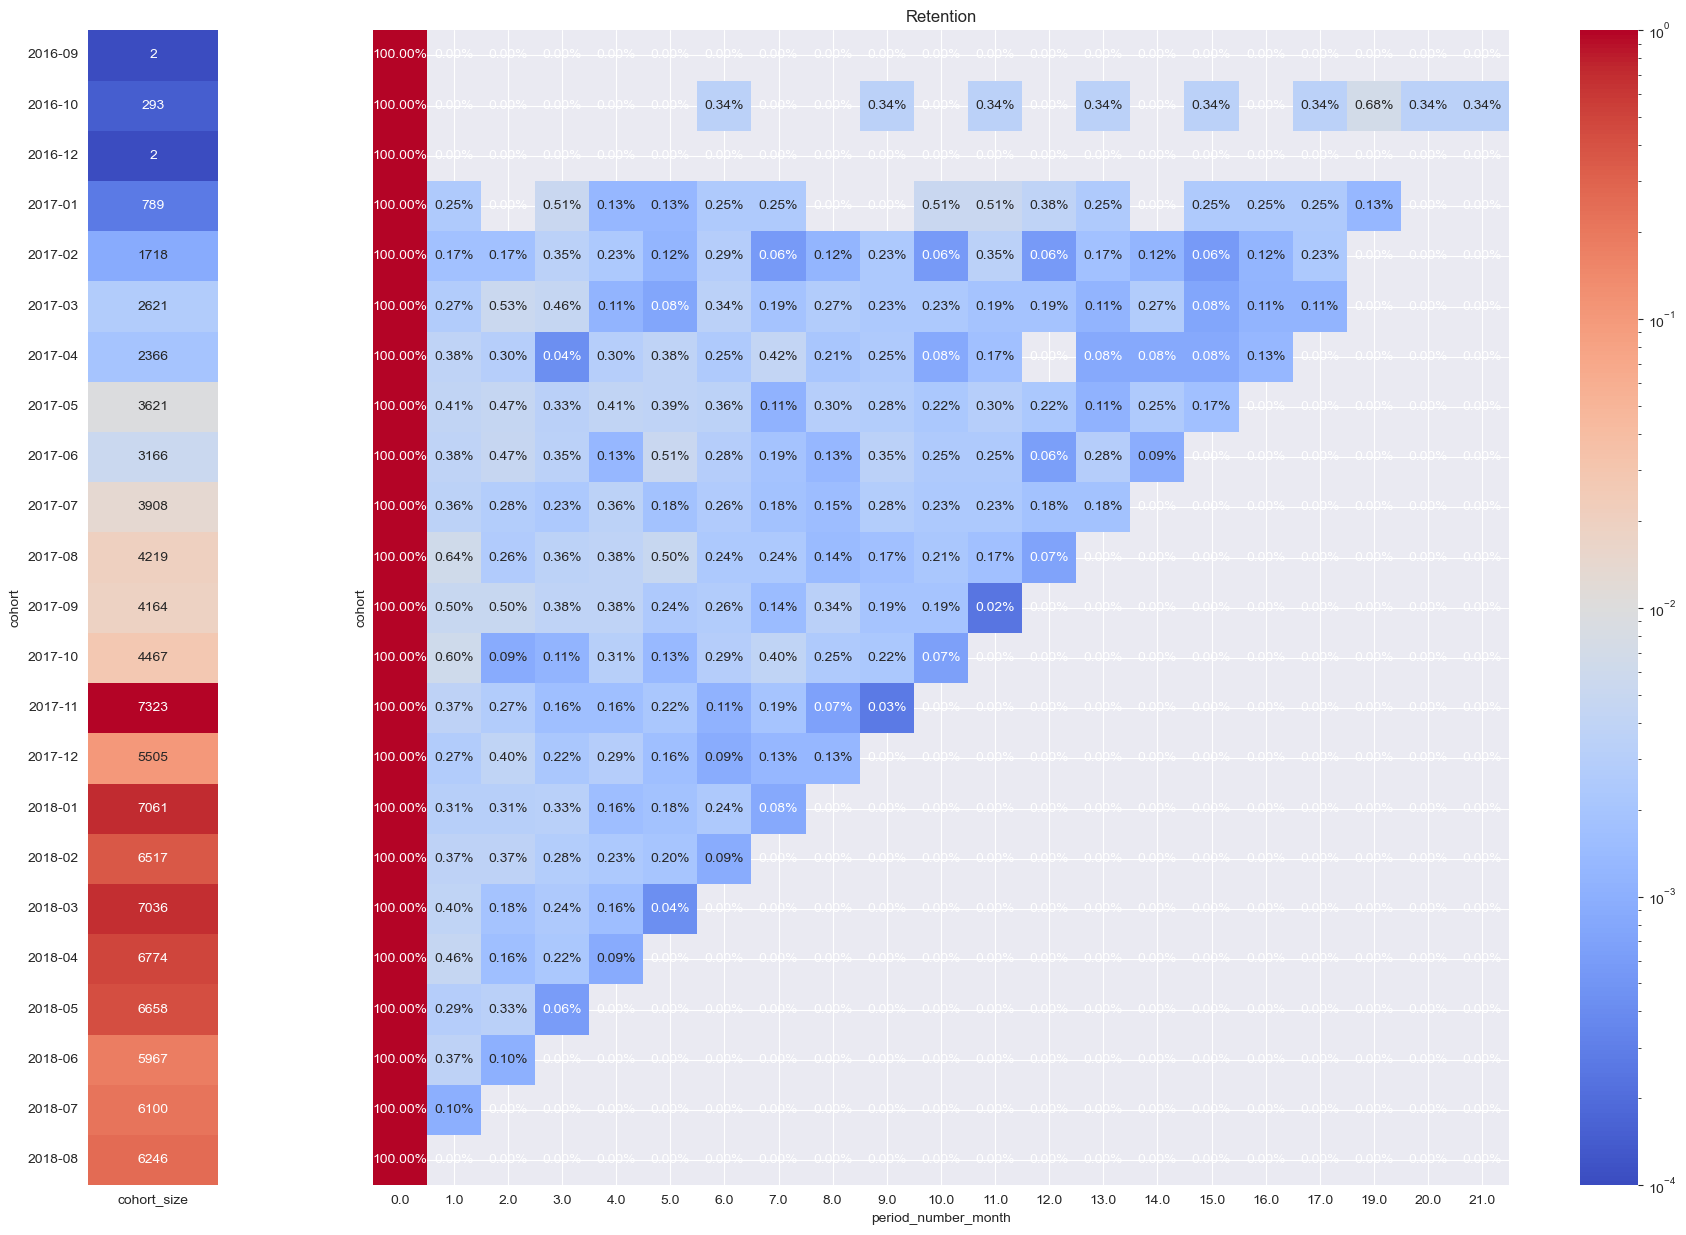

In [86]:
#Визуализируем результаты
fig, axes = plt.subplots(1,2, figsize = (22, 15), sharey = True, gridspec_kw = {'width_ratios': [1,11]})
sns.heatmap(df_pivot, mask = df_pivot.isnull(), annot = True, fmt = '.2%', ax = axes[1], cmap = 'coolwarm', norm=LogNorm(vmin=0.0001, vmax=1))
mask = df_pivot > 0
axes[1].set_title('Retention')
cohort_size_df = pd.DataFrame(cohort_size).rename(columns = {0: 'cohort_size'})
sns.heatmap(cohort_size_df, annot = True, cbar = False, ax = axes[0], fmt = 'g', cmap = 'coolwarm')


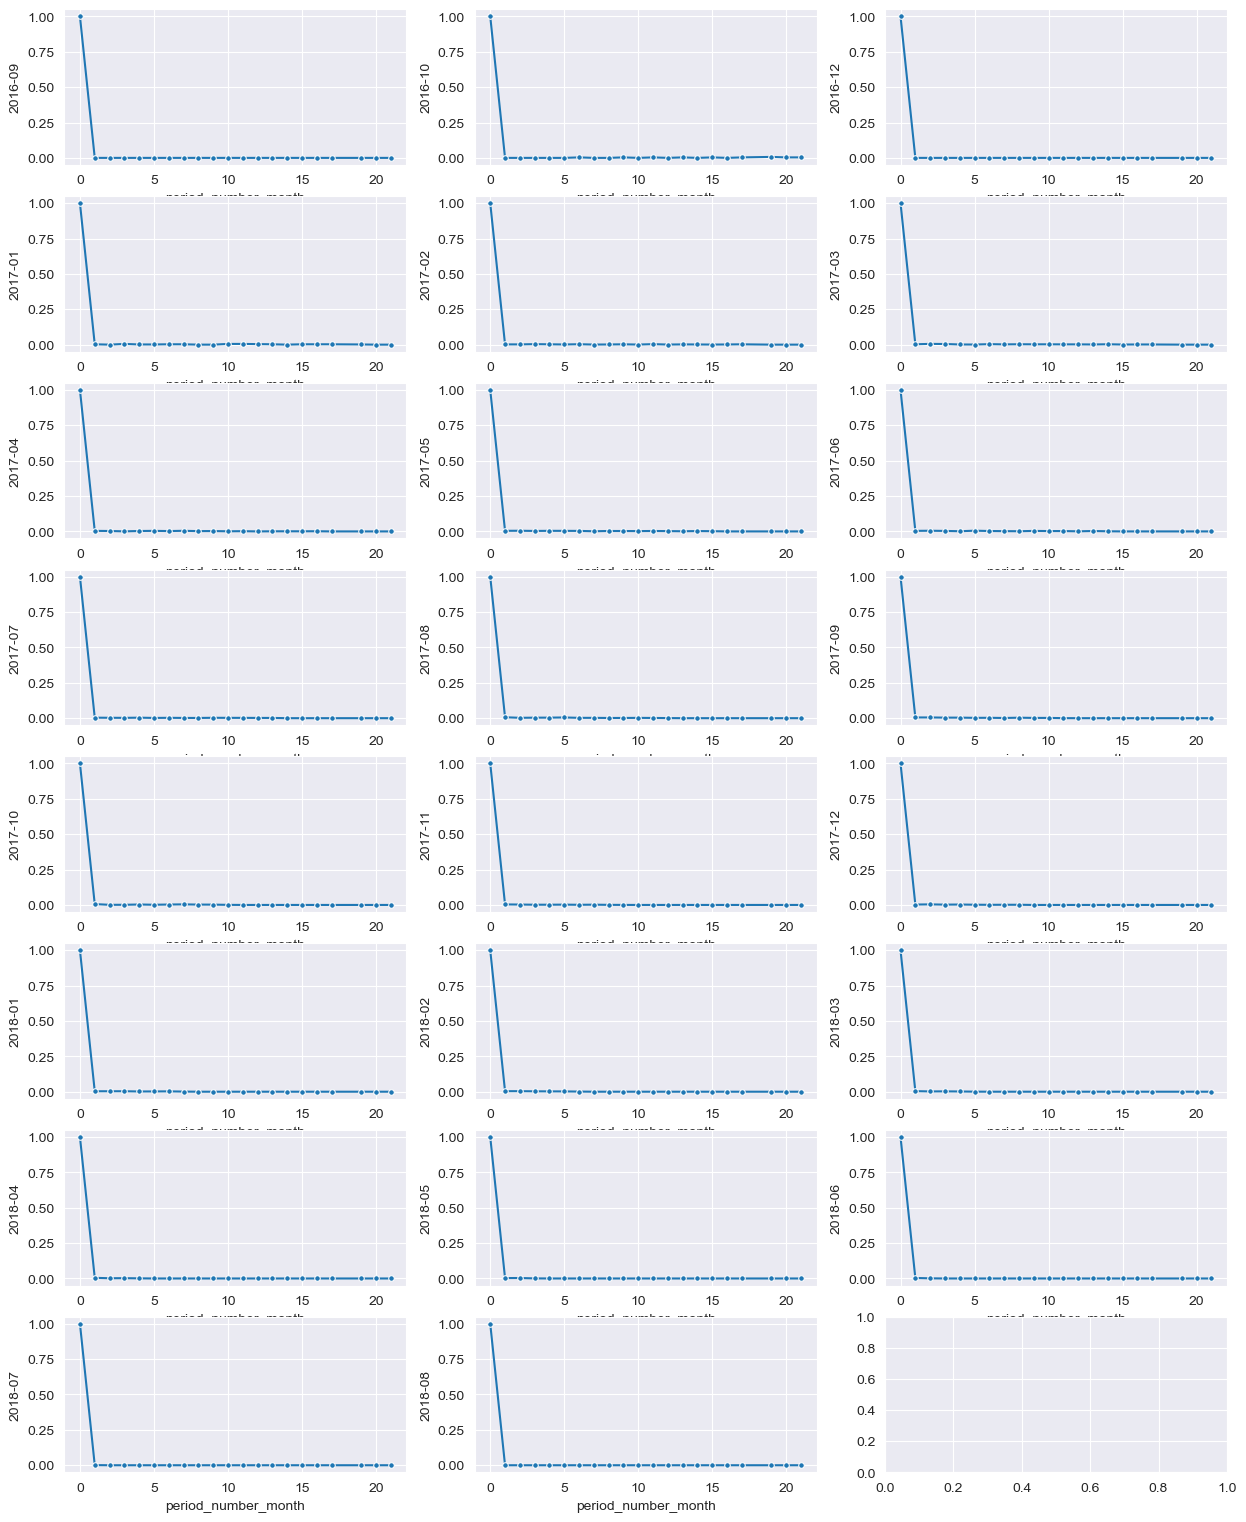

In [87]:
fig, axes = plt.subplots(8,3, figsize = (15,19))
k = [0,0]
for i in df_pivot.index:
    sns.lineplot(x = df_pivot.columns, y = df_pivot.loc[i, :], marker = 'o', markersize = 4, ax = axes[k[0], k[1] % 3])
    k[1] = k[1] + 1
    if k[1] % 3 == 0:
        k[0] = k[0] + 1


На графиках хорошо видно, что количество клиентов, которые совершают повторный заказ, минимальна во всех когортах, что говорит об отсутствии PMF. Отсутствие PMF может быть связано с ассортиментом маркетплейса (только товары из Бразилии, это очень нишевая категория). Кроме того, нужно учитывать логистические сложности (не все пользователи будут повторно заказывать при длительном ожидании заказа). Для решения проблемы маркетплейс может изменить ассортимент в сторону товаров регулярного потребления.

### Анализ продуктовых метрик

Выбор метрик:
1. Рост объёма продаж - Gross Merchandise Volume (GMV);
2. Объем аудитории, которой продукт доставляет ценность - MAU;
3. Заинтересованность новых клиентов в продукте - New User Activation Rate;
4. Вовлеченность клиента в продолжение использования продукта - Retention Rate;
5. денежное выражение вовлеченности клиента - Lifetime Value (LTV). 

In [88]:
#Объединяем с товарными позициями для нахождения GMV.
df_orders_completed_items = pd.merge(df_orders_completed, df_order_items, on = 'order_id', how = 'left')

In [89]:
df_orders_completed_items.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,order_period_day,cohort,cohort_day,period_number_month,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,2017-10-02,2017-09,2017-09-04,0.0,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,2018-07-24,2018-07,2018-07-24,0.0,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,2018-08-08,2018-08,2018-08-08,0.0,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,2017-11-18,2017-11,2017-11-18,0.0,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,2018-02-13,2018-02,2018-02-13,0.0,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72


In [90]:
df_gmv = df_orders_completed_items.groupby('order_period', as_index = False).agg(GMV = ('price', 'sum'))
df_gmv['order_period'] = df_gmv['order_period'].dt.to_timestamp()

<Axes: xlabel='order_period', ylabel='GMV'>

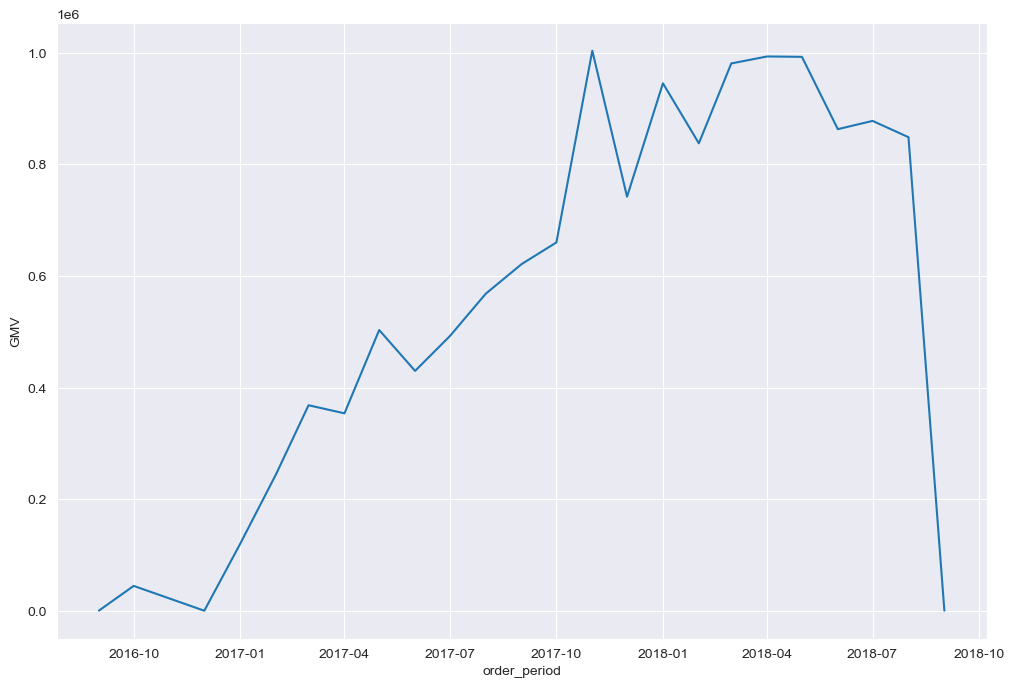

In [91]:
#Визуализируем метрику GMV
plt.figure(figsize = (12,8))
sns.lineplot(data = df_gmv, x = 'order_period', y = 'GMV')

In [92]:
df_mau = df_orders_completed_items.groupby('order_period', as_index = False).agg(mau = ('customer_unique_id', 'nunique'))
df_mau['order_period'] = df_mau['order_period'].dt.to_timestamp()

<Axes: xlabel='order_period', ylabel='mau'>

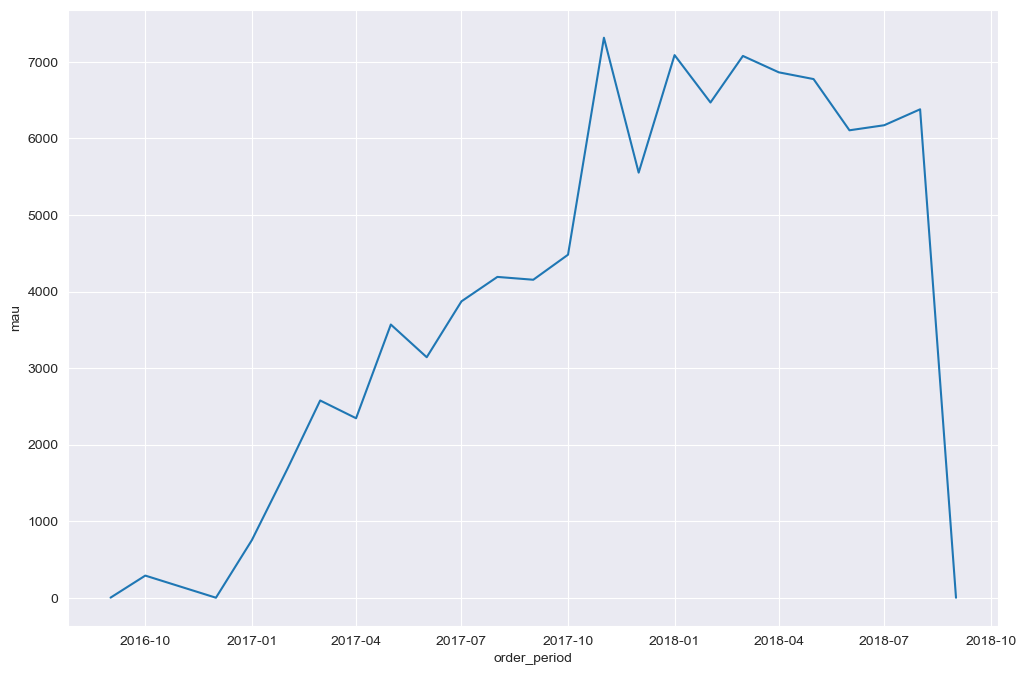

In [93]:
#Визуализируем MAU
plt.figure(figsize = (12,8))
sns.lineplot(data = df_mau, x = 'order_period', y = 'mau')

In [94]:
#Считаем LTV с нарастающим итогом
user_first_month = (df_orders_completed_items.groupby('customer_unique_id', as_index = False)
.agg(first_month = ('order_period', 'min'))
                   )
ltv_data = []
for i in sorted(df_orders_completed_items['order_period'].unique()):
    active_users = user_first_month.loc[user_first_month['first_month'] <= i, 'customer_unique_id']
    ltv = (df_orders_completed_items[df_orders_completed_items['customer_unique_id'].isin(active_users)]
           .groupby('customer_unique_id')['price'].sum().mean()
          )
    ltv_data.append((i.to_timestamp(), ltv))
LTV = pd.Series(dict(ltv_data)).sort_index()

<Axes: xlabel='None'>

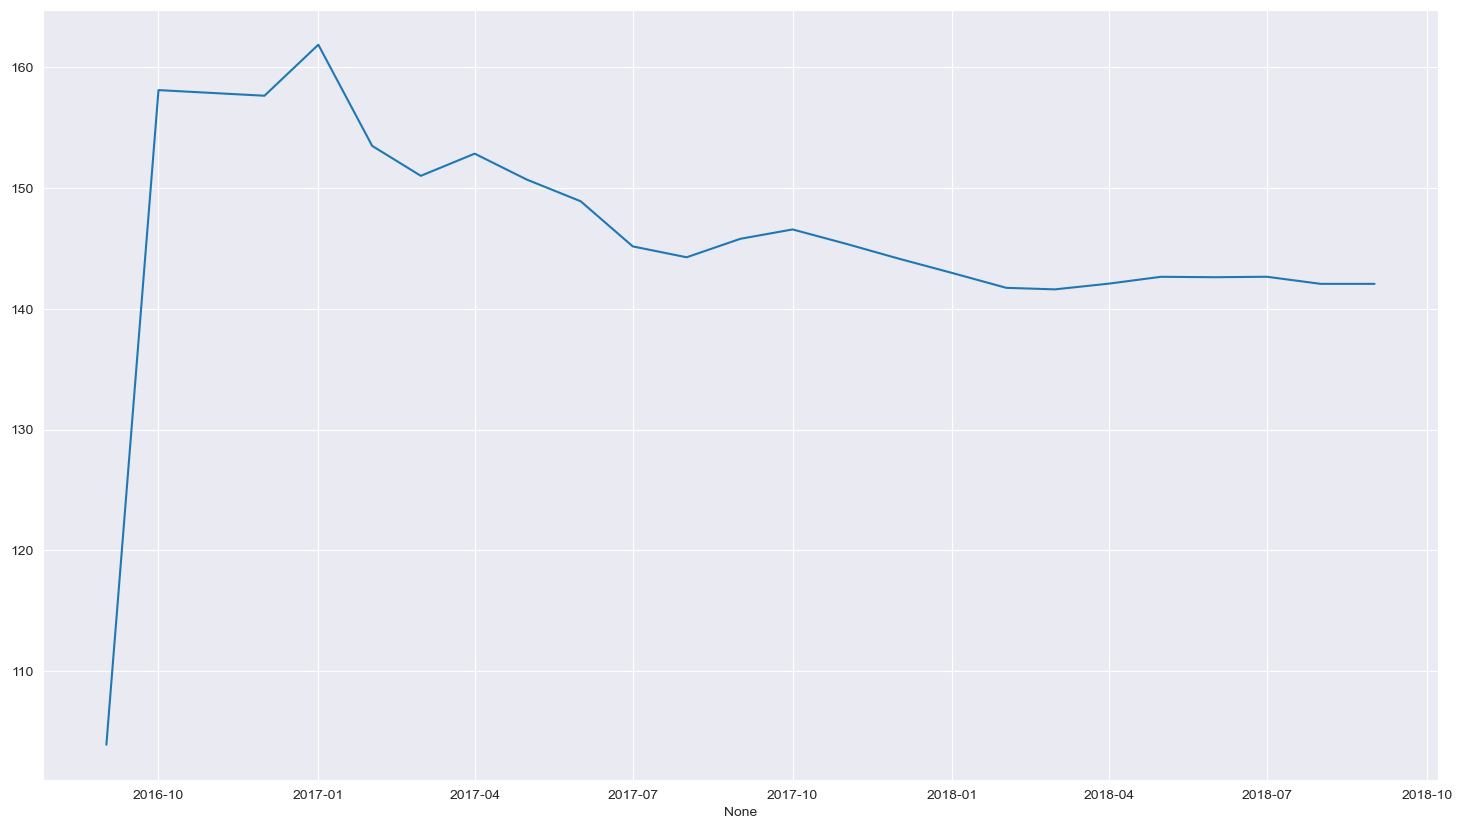

In [95]:
#Визуализируем LTV
plt.figure(figsize = (18,10))
sns.lineplot(x = LTV.index, y = LTV.values)

#### Приоритизация гипотез

In [96]:
#Impact гипотезы 1
df_orders_ice = df_orders[df_orders['order_purchase_timestamp'] >= '2017-06-01'].copy()
impact_h1 = df_orders_ice[df_orders_ice['order_status'].isin(['unvailable','canceled'])].shape[0]

In [97]:
#Impact гипотезы 2
impact_h2 = round(df_orders_ice[df_orders_ice['order_status'] == 'delivered'].shape[0]*median_retention)
impact_h2

306

In [98]:
#Impact гипотезы 3
df_group_orders = (df_orders_ice
             .groupby('customer_unique_id').agg(amount = ('order_id', 'count'))
            )
impact_h3 = round(df_group_orders[df_group_orders['amount'] == 1].shape[0]*median_retention)

In [99]:
def impact_score(additional_orders):
    if additional_orders <= 50:
        return 1
    elif additional_orders <= 150:
        return 2
    elif additional_orders <= 350:
        return 3
    elif additional_orders <= 750:
        return 4
    elif additional_orders <= 1550:
        return 5
    elif additional_orders <= 3150:
        return 6
    elif additional_orders <= 6350:
        return 7
    elif additional_orders <= 12750:
        return 8
    elif additional_orders <= 25550:
        return 9
    else:
        return 10
impact = [impact_h1, impact_h2, impact_h3]
impact_10 = {'h1': 0, 'h2':0, 'h3': 0}
j = 1
for i in impact:
    impact_10[f'h{j}'] = impact_score(i)
    j += 1
impact_10
    

{'h1': 4, 'h2': 3, 'h3': 3}

In [100]:
ice = {'h1': 48, 'h2': 40, 'h3': 45}
for i,j in impact_10.items():
    ice[i] = ice[i]*j
ice

{'h1': 192, 'h2': 120, 'h3': 135}

Выбираем гипотезу 1

#### Проектирование A/B-теста

Гипотеза: Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, вследствие чего количество доставленных заказов увеличится. 

Целевая метрика: доля успешно доставленных заказов Delivered_Rate - напрямую отражает результат эксперимента;

Proxy метрика: доля отменённых заказов. Поскольку баги в процессинге могут увеличивать долю отмены заказов, эта метрика будет ранним индикатором успешности гипотезы; 

Guardrail-метрика: среднее время доставки. Позволяет отследить, как эксперимент повлиял на общее качество сервиса.


#### Отчёт

##### Формализация проблемы продукта. 
Как было выявлено в ходе исследования, основной проблемой продукта является низкое удержание пользователей. Это удалось определить следующим образом:  
1. Результаты когортного анализа, демонстрирующие отсутствие product/market fit;
2. Показатели месячного retention оказались низкими;
3. Низкий показатель повторных заказов.

##### Выводы.  
В рамках исследования были выполнены:  
1. Когортный анализ retention;
2. Оценка product/market fit;
3. Определение ключевых метрик;
4. Приоритизация гипотез с использованием фреймворка ICE.  

Вывод: Большинство клиентов совершают одну покупку и не возвращаются в продукт, что ограничивает рост маркетплейса. Отсутствие product/market fit говорит о том, что продукт не формирует достаточную пользовательскую ценность. Приоритизация гипотез через ICE показала, что наиболее перспективным является исправление бага в системе процессинга заказов.

##### Рекомендации.  
1. Устранение багов в система процессинга заказов.  
Это позволит уменьшить количество отменённых заказов и увеличить количество успешно доставленных заказов.  
2. Провести A/B-тестирование изменений.  
Для оценки эффективности использовать следующие метрики: доля успешно доставленных заказов (target metric), доля отменённых заказов (proxy metric), среднее время доставки (guardrail metric).  
3. Акцентировать внимание на росте retention.  

